In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

In [2]:
B, N, E = 1, 16, 32

In [7]:
tokens = torch.randint(low=0, high=10, size=(1, N))
tokens

tensor([[5, 6, 2, 8, 8, 6, 4, 3, 6, 5, 8, 0, 1, 6, 4, 3]])

In [8]:
token_embedding_table = torch.randn(10, E)

In [10]:
token_embedding_table[5]

tensor([-0.0375, -0.4247,  0.4430, -0.7245, -2.3177, -0.5951, -0.4377, -0.6556,
        -0.6308,  0.1211,  0.6935, -0.3870,  0.1919,  0.3884, -0.9755, -0.9559,
        -1.3813,  0.6591,  0.1900,  0.0403,  1.1090,  1.2236, -0.4816,  0.2467,
         1.4921, -0.2320,  0.3803, -0.8646, -0.5551,  0.1975, -2.3983,  1.1848])

In [13]:
x = token_embedding_table[tokens]
x.shape

torch.Size([1, 16, 32])

In [19]:
x.transpose(-2, -1).shape

torch.Size([1, 32, 16])

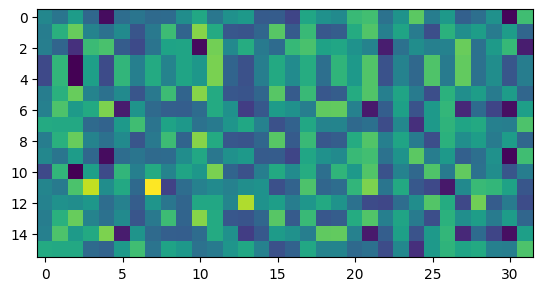

In [20]:
plt.imshow(x[0])

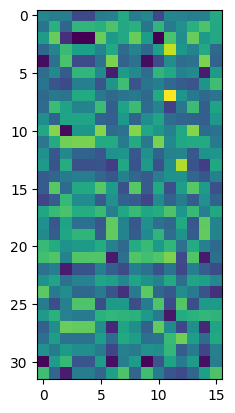

In [21]:
plt.imshow(x.transpose(-2, -1)[0])

In [22]:
attn_weights = x@x.transpose(-2, -1)

In [ ]:
tok

<function matplotlib.pyplot.show(close=None, block=None)>

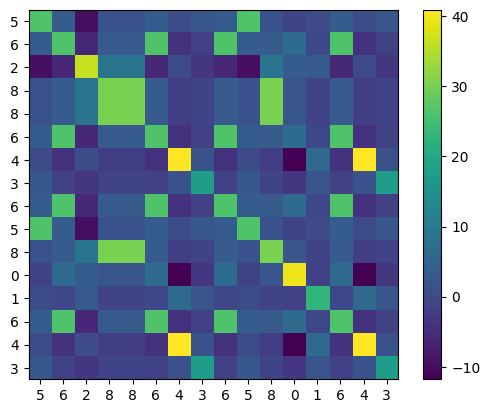

In [38]:
plt.imshow(attn_weights[0])
plt.xticks([i for i in range(16)], tokens[0].tolist())
plt.yticks([i for i in range(16)], tokens[0].tolist())
plt.colorbar()
plt.show

tensor([[[False,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True],
         [False, False,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True],
         [False, False, False,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True],
         [False, False, False, False,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True],
         [False, False, False, False, False,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True],
         [False, False, False, False, False, False,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True],
         [False, False, False, False, False, False, False,  True,  True,  True,
           True,  True,  True,  True,  True,  True],
         [False, False, False, False, False, False, False, False,  Tr

In [39]:
attn_weights = attn_weights.masked_fill(torch.tril(torch.ones_like(attn_weights)) == 0.0, float('-inf'))

In [41]:
attn_weights = attn_weights.softmax(dim=-1)

<function matplotlib.pyplot.show(close=None, block=None)>

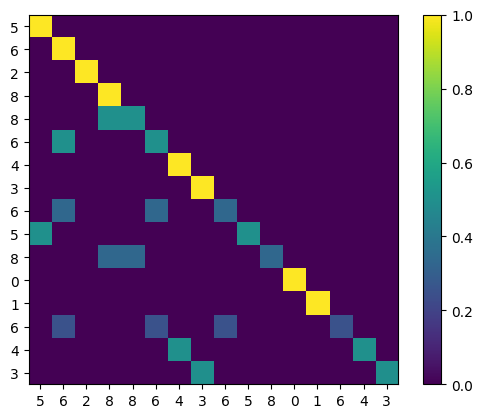

In [42]:
plt.imshow(attn_weights[0])
plt.xticks([i for i in range(16)], tokens[0].tolist())
plt.yticks([i for i in range(16)], tokens[0].tolist())
plt.colorbar()
plt.show

In [43]:
attn_weights.shape, x.shape

(torch.Size([1, 16, 16]), torch.Size([1, 16, 32]))

In [44]:
out = attn_weights @ x

In [45]:
out.shape

torch.Size([1, 16, 32])